In [1]:
#importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 


In [2]:
df=pd.read_csv("mnist_train.csv")
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
#Shape and size of the dataset
print(df.shape)
print(df.size)

(60000, 785)
47100000


In [4]:
df['label'].value_counts() #to check the number of samples for each class

label
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

In [5]:
x=df.drop('label',axis=1).values#independent variable
y=df['label']#dependent variable

In [6]:
x[1]#to check the pixel values of the first image in the dataset

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 159, 253,
       159,  50,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238,
       252, 252, 252, 237,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

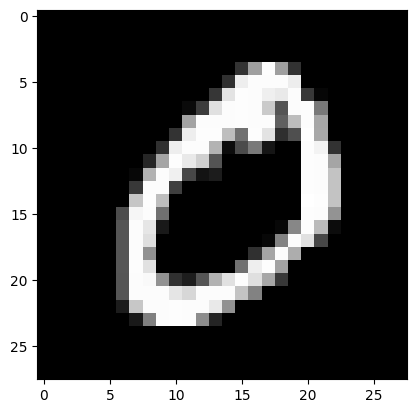

In [7]:
plt.imshow(x[1].reshape(28,28),cmap='gray')#to check the label of the first image in the dataset
plt.show()

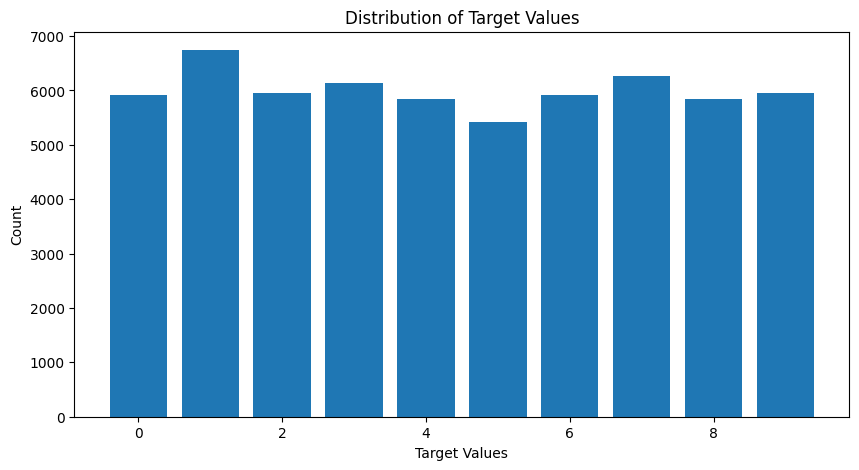

In [8]:
plt.figure(figsize=(10,5))#to set the size of the plot
plt.bar(df['label'].value_counts().index,df['label'].value_counts().values)
plt.xlabel('Target Values')
plt.ylabel('Count')
plt.title('Distribution of Target Values')
plt.show()


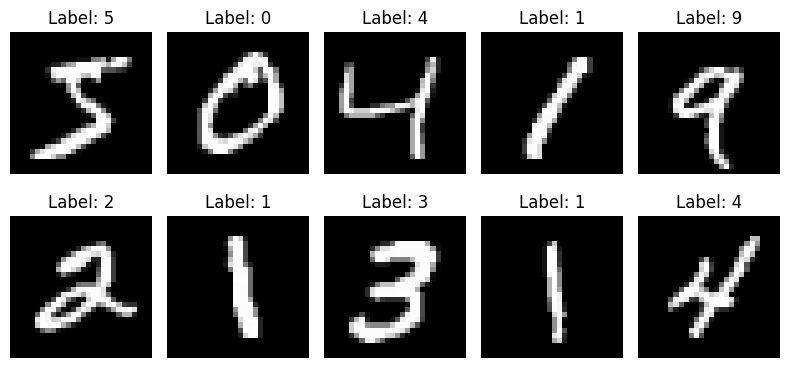

In [9]:
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)#to create a grid of 2 rows and 5 columns for plotting the images
    plt.imshow(x[i].reshape(28,28),cmap='gray')#to reshape the 1D array of pixel values into a 2D array of 28x28 and display it as a grayscale image
    plt.title(f'Label: {y[i]}')#to set the title of each subplot to show the corresponding label of the image
    plt.axis('off')#to hide the axes for better visualization

plt.tight_layout()
plt.show()

In [10]:
# Normalize pixel values
x=x/255.0#to scale the pixel values to the range [0, 1] by dividing each pixel value by 255, which is the maximum possible pixel value in an 8-bit grayscale image. This normalization step helps improve the performance of machine learning models by ensuring that all input features are on a similar scale.

In [11]:
#Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split    
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout

model = Sequential()
model.add(Dense(256,activation='relu',input_shape=(784,)))
model.add(Dropout(0.3))
model.add(Dense(132,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(64,activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(32,activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(16,activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(10,activation='softmax'))

C:\Users\arpan\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# complie the model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [14]:
# model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 132)            │        33,924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 132)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 246,174 (961.62 KB)

 Trainable params: 246,174 (961.62 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.fit(x_train, y_train, epochs = 20, batch_size = 64, validation_split = 0.2)

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7118 - loss: 0.8926 - val_accuracy: 0.9386 - val_loss: 0.2217
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9102 - loss: 0.3490 - val_accuracy: 0.9553 - val_loss: 0.1636
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9346 - loss: 0.2646 - val_accuracy: 0.9610 - val_loss: 0.1468
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9443 - loss: 0.2182 - val_accuracy: 0.9617 - val_loss: 0.1444
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9541 - loss: 0.1917 - val_accuracy: 0.9678 - val_loss: 0.1342
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9593 - loss: 0.1702 - val_accuracy: 0.9686 - val_loss: 0.1264
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9617 - loss: 0.1582 - val_accuracy: 0.9657 - val_loss: 0.1413
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9649 - loss: 0.1445 - val_accuracy: 0.

In [16]:
model.save("mnist_mlp1_model1.h5")

In [17]:
# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("Accuracy:", acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9762 - loss: 0.1159
Accuracy: 0.9762499928474426


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
y_pred = model.predict(x_test)
y_pred_classes = y_pred.argmax(axis=1)
print(classification_report(y_test, y_pred_classes))

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1175
           1       0.97      0.99      0.98      1322
           2       0.96      0.98      0.97      1174
           3       0.98      0.96      0.97      1219
           4       0.98      0.98      0.98      1176
           5       0.98      0.97      0.97      1104
           6       0.98      0.99      0.99      1177
           7       0.98      0.98      0.98      1299
           8       0.97      0.96      0.97      1160
           9       0.97      0.97      0.97      1194

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



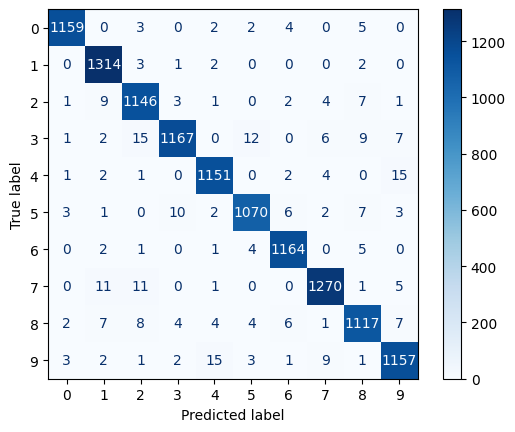

In [19]:
# display confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

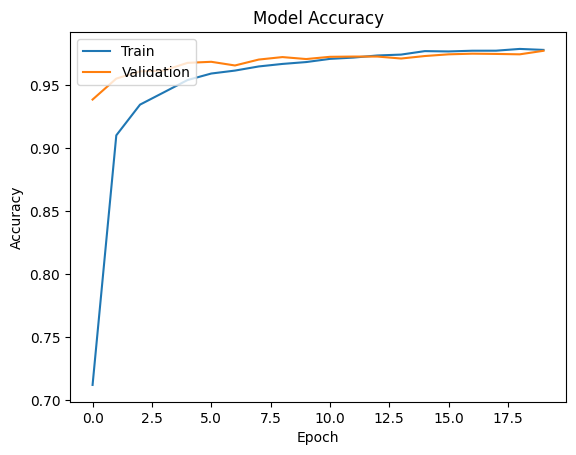

In [20]:
# plot epoch vs accuracy graph
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'],loc='upper left')
plt.show()

Training vs Validation Accuracy (Graph):-------

The graph shows accuracy across epochs.

Observations:------

Training accuracy increases from ~91% to ~99.5%.

Validation accuracy increases from ~95% to ~97–97.6%.

The curves rise quickly in the first few epochs and then stabilize.

Interpretation:------

The model learns quickly in early epochs.

Training accuracy is higher than validation accuracy, which is normal.

The gap between them is small (~2%), meaning overfitting is minimal.

This indicates a well-trained model with good generalization.

Final Interpretation:-----

The model achieves about 97.5% accuracy on the MNIST dataset, with high precision, recall, and F1-scores for all digits. The training and validation curves show stable learning with minimal overfitting, indicating that the model generalizes well to unseen handwritten digit images.